In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, \
    confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.layers import Input, InputLayer, Conv2D, MaxPool2D, GlobalAveragePooling2D, BatchNormalization, Activation, ReLU, Flatten, Dense, Add,\
    Dropout,MaxPooling2D,Concatenate,Reshape
from tensorflow.keras.models import Sequential, Model
import tensorflow as tf
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
labels = ['Early Blight', 'Fungal Diseases','Healthy','Late Blight','Plant Pests','Potato Cyst Nematode','Potato Virus']

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['AbhishekResume.pdf', 'Abhishek BCA Major Project Movie Recommendation System.pdf', 'Abhishek Resume (1).pdf', 'House Price Prediction.pdf', 'pdf minor project Sentiment Analysis.pdf', 'PPT House Price prediction.pptx', 'Abhishek', 'enquiry .pdf', 'Abhishek Resume.pdf', 'Abhishek Resume new.pdf', 'Abhishek MCA.pdf', 'Abhishek Resume aml1_250307_185759.pdf', 'Generated PDF from Image Files (1).pdf', 'Generated PDF from Image Files.pdf', 'mtech-1-sem-foundation-of-computer-science-mtcs101-2018_copy.pdf', 'Chapter 8 Software Testing_251005_094550.pdf', 'WHAT-IS-RESEARCH._copy.pdf', 'EnhancingDisasterResponseSystemsPredictingandMitigatingtheImpactofNaturalDisastersUsingAI_copy.pdf', 'jwc0111766_copy (1).pdf', 'jwc0111766_copy.pdf', 'plants-08-00468-v3 (1)_copy.pdf', '10.1109ICICCS48265.2020.9121067_copy.pdf', 'potato-leaf-disease-detection-using-deep-learning-IJERTV11IS110029_copy.pdf', 'IJEM-V13-N6-2_copy.pdf', 'Shreha Practical file _260106_002404.pdf', 'Untitled document.gdoc', 'Untitl

In [ ]:
dataset_path = '/content/drive/MyDrive/PotatoLeafDIsease'

print(os.listdir(dataset_path))

['Potato Cyst Nematode', 'Early Blight', 'Fungal Diseases', 'Late Blight', 'Healthy', 'Potato Virus', 'Plant Pests']


"""Image resize to 224*224
#import tensorflow as tf

#IMAGE_SIZE = 124
#BATCH_SIZE = 32

#dataset = tf.keras.utils.image_dataset_from_directory(
 #   dataset_path,
  #  shuffle=True,
   # image_size=(IMAGE_SIZE, IMAGE_SIZE),
    #batch_size=BATCH_SIZE)

#print(dataset.class_names)"""


In [ ]:
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
#Since we don't have a CSV file, we are creating a CSV file that contains our images including File, Disease Id, and Disease Type.
data=[]
for disease_id , sp in enumerate(labels):
    for file in os.listdir(os.path.join(dataset_path, sp)):
        data.append(['{}/{}'.format(sp, file), disease_id, sp])
csv_data = pd.DataFrame(data, columns=['File', 'Disease Id', 'Disease Type'])
csv_data

,File,Disease Id,Disease Type
0,Early Blight/early blight (117).JPG,0,Early Blight
1,Early Blight/early blight (110).JPG,0,Early Blight
2,Early Blight/early blight (150).JPG,0,Early Blight
3,Early Blight/early blight (140).JPG,0,Early Blight
4,Early Blight/early blight (118).JPG,0,Early Blight
...,...,...,...
3495,Potato Virus/potato virus (178).jpg,6,Potato Virus
3496,Potato Virus/potato virus (356).jpg,6,Potato Virus
3497,Potato Virus/potato virus (127).jpg,6,Potato Virus
3498,Potato Virus/potato virus (130).jpg,6,Potato Virus


In [ ]:
csv_data.isnull().sum()

,0
File,0
Disease Id,0
Disease Type,0


In [ ]:
# Resize image to 112* 112
IMAGE_SIZE = 112

def read_image(filepath):
    return cv2.imread(os.path.join(dataset_path, filepath))
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)



In [ ]:
import numpy as np
X_data_item = np.zeros((csv_data.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(csv_data['File'].values)):
    image = read_image(file)
    if image is not None:
        X_data_item[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
# Normalize data
X_data = X_data_item /255.0
print('Train Shape: {}'.format(X_data.shape))

Y_data = csv_data['Disease Id'].values
Y_data = to_categorical(Y_data)

3500it [00:15, 228.05it/s]


Train Shape: (3500, 112, 112, 3)


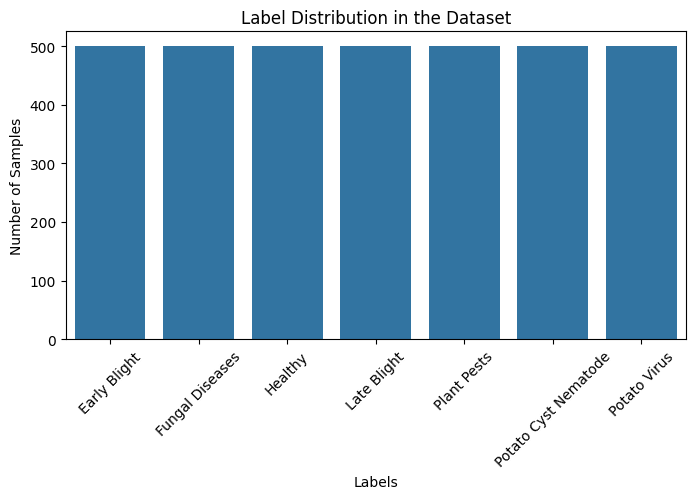

In [ ]:
class_counts = csv_data['Disease Type'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel('Labels')
plt.ylabel('Number of Samples')
plt.title('Label Distribution in the Dataset')
plt.xticks(rotation=45)
plt.show()

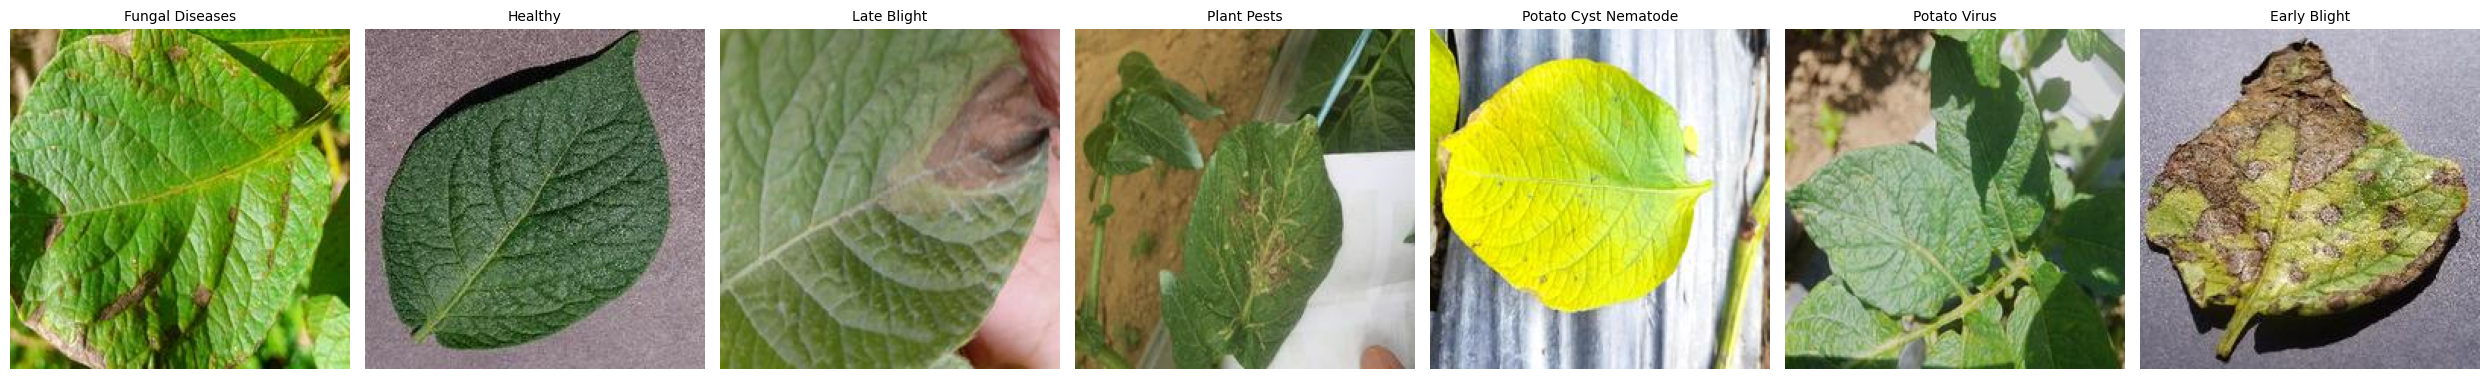

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

categories = [
    'Fungal Diseases',
    'Healthy',
    'Late Blight',
    'Plant Pests',
    'Potato Cyst Nematode',
    'Potato Virus',
    'Early Blight'
]

fig, axs = plt.subplots(1, 7, figsize=(25, 5))

for j, category in enumerate(categories):

    # Filter images for this category
    category_data = csv_data[
        csv_data['Disease Type'] == category
    ]

    # Select one random image
    random_row = category_data.sample(n=1).iloc[0]

    img_path = random_row['File']

    # Open image
    img = Image.open(
        str(dataset_path) + "/" + img_path
    )

    # Display
    axs[j].imshow(img)
    axs[j].set_title(category, fontsize=10)
    axs[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Temporary
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_data,
    Y_data,
    test_size=0.20,
    random_state=42,
    stratify=Y_data
)

# Split the remaining 20% equally:
# 10% Validation + 10% Testing
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    stratify=Y_temp
)

# Print shapes
print("Training data:", X_train.shape, Y_train.shape)
print("Validation data:", X_val.shape, Y_val.shape)
print("Testing data:", X_test.shape, Y_test.shape)

Training data: (2800, 112, 112, 3) (2800, 7)
Validation data: (350, 112, 112, 3) (350, 7)
Testing data: (350, 112, 112, 3) (350, 7)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =====================================================
# 1. Number of training images BEFORE augmentation
# =====================================================

print("Number of training images before augmentation:",
      X_train.shape[0])


# =====================================================
# 2. Define Data Augmentation Techniques
# =====================================================

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)


# =====================================================
# 3. Generate augmented training images
# =====================================================

augmented_generator = datagen.flow(
    X_train,
    Y_train,
    batch_size=X_train.shape[0],
    shuffle=False
)

X_train_augmented, Y_train_augmented = next(augmented_generator)


# =====================================================
# 4. Combine Original + Augmented Images
# =====================================================

X_train_final = np.concatenate(
    [X_train, X_train_augmented],
    axis=0
)

Y_train_final = np.concatenate(
    [Y_train, Y_train_augmented],
    axis=0
)


# =====================================================
# 5. Display Number of Images
# =====================================================

print("\n========== DATA AUGMENTATION RESULT ==========")

print("Training images BEFORE augmentation:",
      X_train.shape[0])

print("New augmented images:",
      X_train_augmented.shape[0])

print("Training images AFTER augmentation:",
      X_train_final.shape[0])

print("==============================================")

print("\nFinal training data shape:",
      X_train_final.shape)

print("Final training labels shape:",
      Y_train_final.shape)

Number of training images before augmentation: 2800

========== DATA AUGMENTATION RESULT ==========
Training images BEFORE augmentation: 2800
New augmented images: 2800
Training images AFTER augmentation: 5600

Final training data shape: (5600, 112, 112, 3)
Final training labels shape: (5600, 7)


In [ ]:
basemodel = InceptionV3(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet', classes=7) #removes InceptionV3's original ImageNet classification layers.,

flatten_layer = Flatten()(basemodel.output)
dense_layer = Dense(32, activation='relu')(flatten_layer)

dropout_layer = Dropout(0.4)(dense_layer)
output_layer = Dense(7, activation='softmax')(dropout_layer)

model = Model(inputs=basemodel.input, outputs=output_layer);

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
from keras.metrics import Precision, Recall,AUC,F1Score
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # lr=0.0001 , 0.1
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', Precision(), Recall(), AUC(), F1Score()])


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

class EarlyStoppingAtThreshold(tf.keras.callbacks.Callback):
      def __init__(self, monitor, threshold, patience = 0, restore_best_weights=False):
        super(EarlyStoppingAtThreshold, self).__init__()
        self.monitor = monitor # izlenmesi gereken metrik
        self.threshold = threshold # hangi değerde duracağımız
        self.patience = patience # o değere ulaştıktan sonra kaç epoch devam etsin
        self.restore_best_weights = restore_best_weights # en iyi ağırlıklar
        self.wait = 0 # bunu wait > patience için tanımlandı
        self.best_weights = None # en iyi ağırlıklarımızı tutacak
        self.best = -float('inf') # metriğin en yüksek değeri

      def on_train_begin(self, logs=None): # eğitime başlangıç anında olacaklar
        self.wait = 0
        self.best = -float('inf')
        if self.restore_best_weights: # True ise modelin ilk ağırlığını best_weights e atacak
            self.best_weights = self.model.get_weights()

      def on_epoch_end(self, epoch, logs=None): # Her epoch sonunda olacaklar
        current = logs.get(self.monitor) # izlencek metriğin değerini çekiyoruz
        if current is None:
            print(f"Warning: Metric '{self.monitor}' is not available.")
            return

        if current > self.best: # eğer metriğin değeri öncekinden yüksekse
            self.best = current # en yüksek metirk değerini değiştiriyoruz
            self.wait = 0
            if self.restore_best_weights: # true ise
                self.best_weights = self.model.get_weights() # en iyi ağırlığı güncelliyoruz
        elif current >= self.threshold: # metriğin değeri istediğimiz değeri geçtiyse
            self.wait += 1 # beklemeyi 1 arttırıyoruz
            if current > self.best:
                self.best = current
                if self.restore_best_weights: # true ise
                    self.best_weights = self.model.get_weights()
            if self.wait > self.patience: # wait > patience olunca
                # istediğimiz değere geldi durduruyoruz
                print(f"\nReached {self.threshold*100}% {self.monitor}. Stopping training after {self.patience} more epochs.")
                if self.restore_best_weights:# True ise
                    print("Restoring model weights from the best epoch.")
                    self.model.set_weights(self.best_weights)# en iyi ağırlıkları ayarlıyoruz
                self.model.stop_training = True #modeli durduruyoruz

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5, cooldown=3, min_lr=1e-4, verbose=1)

early_stopping = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=10, restore_best_weights=False)

early_stoppin_at_threshold = EarlyStoppingAtThreshold(monitor='val_accuracy', threshold=0.94, patience = 0, restore_best_weights=True)

calbacks=[early_stopping,reduce_lr,early_stoppin_at_threshold]

In [ ]:
batch_size = 64
epochs = 5
hist_concat = model.fit(
    [X_train_final],Y_train_final,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=([X_val],Y_val),
    callbacks=calbacks
    )

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 820s 9s/step - accuracy: 0.2534 - auc: 0.6471 - f1_score: 0.1945 - loss: 1.8222 - precision: 0.8068 - recall: 0.0507 - val_accuracy: 0.2143 - val_auc: 0.5545 - val_f1_score: 0.1173 - val_loss: 135.8550 - val_precision: 0.2240 - val_recall: 0.2029 - learning_rate: 0.0010
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 762s 9s/step - accuracy: 0.2993 - auc: 0.7481 - f1_score: 0.2255 - loss: 1.6569 - precision: 0.8555 - recall: 0.1036 - val_accuracy: 0.3029 - val_auc: 0.7092 - val_f1_score: 0.2423 - val_loss: 8.4424 - val_precision: 0.5067 - val_recall: 0.1086 - learning_rate: 0.0010
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 760s 9s/step - accuracy: 0.3370 - auc: 0.7713 - f1_score: 0.2765 - loss: 1.5889 - precision: 0.8483 - recall: 0.1279 - val_accuracy: 0.4200 - val_auc: 0.7393 - val_f1_score: 0.3473 - val_loss: 2.2276 - val_precision: 0.6875 - val_recall: 0.1886 - learning_rate: 0.0010
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 799s 9s/step - accuracy: 0.3302 - auc: 0.76

In [ ]:
y_pred = model.predict([X_test])
y_pred = np.argmax(y_pred, axis=1).reshape(-1, 1)
Y_test = np.argmax(Y_test, axis=1).reshape(-1, 1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step


In [ ]:
def model_result(Y_test,y_pred):
    print(" MODEL RESULTS")
    print("Accuracy: ", accuracy_score(Y_test, y_pred))
    print("F1_Score: ", f1_score(Y_test, y_pred, average='macro'))
    print("Precision: ", precision_score(Y_test, y_pred, average='macro'))
    print("Sensitivity: ", recall_score(Y_test, y_pred, average='macro'))

In [ ]:
import matplotlib.pyplot as plt
def Plot_acc_history(hist_concat):
    plt.plot(hist_concat.history['accuracy'])
    plt.plot(hist_concat.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [ ]:
def Plot_loss_history(hist_concat):
    plt.plot(hist_concat.history['loss'])
    plt.plot(hist_concat.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
def Confusion_matrix(Y_test,y_pred):
    class_names = labels
    print('Test Confusion Matrix')
    cm_dense = confusion_matrix(Y_test, y_pred)
    sn.set(font_scale=1.2)  # for label size
    sn.heatmap(cm_dense, annot=True, fmt="d", linewidths=.5, annot_kws={"size": 16},xticklabels=class_names, yticklabels=class_names)

In [ ]:
model_result(Y_test,y_pred)

 MODEL RESULTS
Accuracy:  0.38285714285714284
F1_Score:  0.3222512909698309
Precision:  0.32688716512245924
Sensitivity:  0.3828571428571429


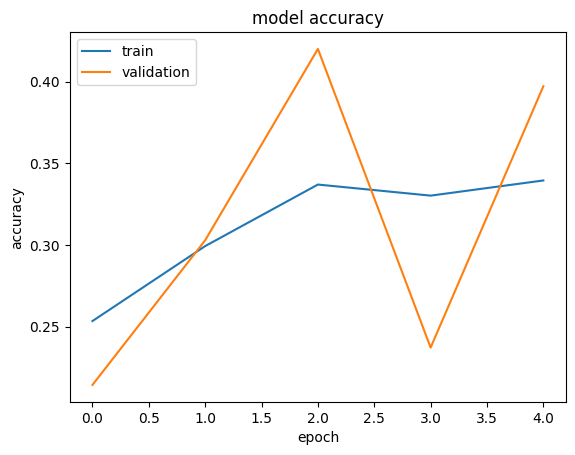

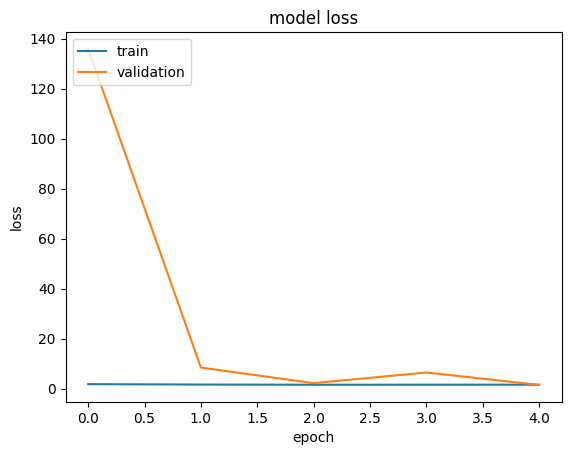

In [ ]:
Plot_acc_history(hist_concat)
Plot_loss_history(hist_concat)

Test Confusion Matrix


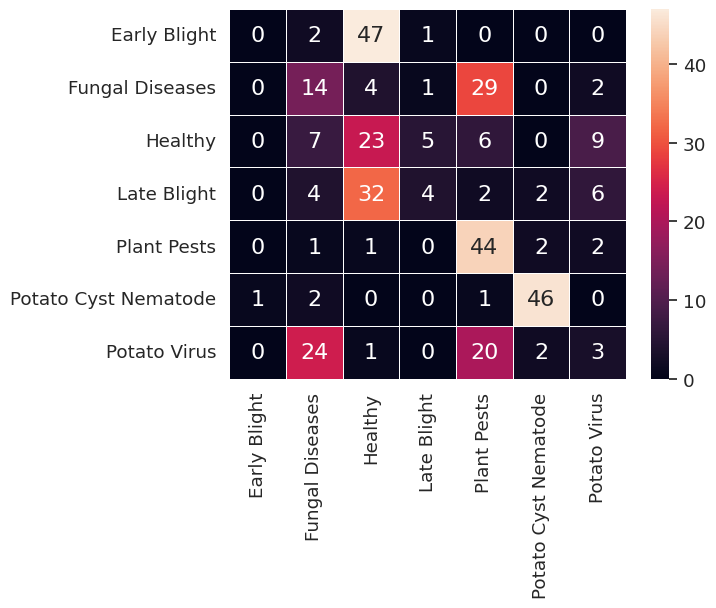

In [ ]:
Confusion_matrix(Y_test,y_pred)

In [ ]:
basemodel = ResNet50(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet', classes=7)

flatten_layer = Flatten()(basemodel.output)
dense_layer = Dense(32, activation='relu')(flatten_layer)
# Dropout ve çıkış katmanı
dropout_layer = Dropout(0.4)(dense_layer)
output_layer = Dense(7, activation='softmax')(dropout_layer)

model = Model(inputs=[basemodel.input], outputs=output_layer);

In [ ]:
from keras.metrics import Precision, Recall,AUC,F1Score
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # lr=0.0001 , 0.1
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', Precision(), Recall(), AUC(), F1Score()])
# model.summary() ön eğitimli ağda çok fazla katman bulunduğu için boş yer kaplıyor

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5, cooldown=3, min_lr=1e-4, verbose=1)

early_stopping = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=10, restore_best_weights=True)

#early_stoppin_at_threshold = EarlyStoppingAtThreshold(monitor='val_accuracy', threshold=0.93, patience = 2, restore_best_weights=True)

calbacks=[early_stopping,reduce_lr]

In [ ]:
batch_size = 64
epochs = 50
hist_concat = model.fit(
    [X_train],Y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=([X_val],Y_val),
    callbacks=calbacks
    )

In [ ]:
y_pred = model.predict([X_test])
y_pred = np.argmax(y_pred, axis=1).reshape(-1, 1)
Y_test = np.argmax(Y_test, axis=1).reshape(-1, 1)

In [ ]:
model_result(Y_test,y_pred)

In [ ]:
Plot_acc_history(hist_concat)
Plot_loss_history(hist_concat)

In [ ]:
Confusion_matrix(Y_test,y_pred)

In [ ]:
basemodel = InceptionV3(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet', classes=7)
basemodel2 = ResNet50(include_top=False)

for layer in basemodel.layers:
    layer.trainable = True
for layer in basemodel2.layers:
    layer.trainable = True

global_pooling_layer1 = GlobalAveragePooling2D()(basemodel.output)
global_pooling_layer2 = GlobalAveragePooling2D()(basemodel2.output)

global_pooling_layer1 = Reshape((1, 1, global_pooling_layer1.shape[1]))(global_pooling_layer1)
global_pooling_layer2 = Reshape((1, 1, global_pooling_layer2.shape[1]))(global_pooling_layer2)

concatenated_output = Concatenate()([global_pooling_layer1, global_pooling_layer2])

flatten_layer = Flatten()(concatenated_output)

dense_layer = Dense(32, activation='relu')(flatten_layer)
# Dropout ve çıkış katmanı
dropout_layer = Dropout(0.4)(dense_layer)
output_layer = Dense(7, activation='softmax')(dropout_layer)

model = Model(inputs=[basemodel.input,basemodel2.input], outputs=output_layer)

In [ ]:
from keras.metrics import Precision, Recall,AUC,F1Score
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # lr=0.0001 , 0.1
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', Precision(), Recall(), AUC(), F1Score()])
# model.summary() ön eğitimli ağda çok fazla katman bulunduğu için boş yer kaplıyor

In [ ]:
batch_size = 64
epochs = 50
hist_concat = model.fit(
    [X_train,X_train],Y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=([X_val,X_val],Y_val),
    callbacks=calbacks
    )

In [ ]:
y_pred = model.predict([X_test,X_test])
y_pred = np.argmax(y_pred, axis=1).reshape(-1, 1)
Y_test = np.argmax(Y_test, axis=1).reshape(-1, 1)

In [ ]:
model_result(Y_test,y_pred)

In [ ]:
Plot_acc_history(hist_concat)
Plot_loss_history(hist_concat)

In [ ]:
Confusion_matrix(Y_test,y_pred)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout

model=Sequential()
model.add(Conv2D(64, kernel_size=3, activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dense(7, activation='softmax'))

In [ ]:
from keras.metrics import Precision, Recall,AUC,F1Score
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # lr=0.0001 , 0.1
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', Precision(), Recall(), AUC(), F1Score()])
model.summary()

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.4, patience=5, cooldown=3, min_lr=1e-4, verbose=1)

early_stopping = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=10, restore_best_weights=True)

#early_stoppin_at_threshold = EarlyStoppingAtThreshold(monitor='val_accuracy', threshold=0.93, patience = 2, restore_best_weights=True)

calbacks=[early_stopping,reduce_lr]

In [ ]:
batch_size = 64
epochs = 50
hist_concat = model.fit(
    [X_train],Y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=([X_val],Y_val),
    callbacks=calbacks
    )

In [ ]:
y_pred = model.predict([X_test])
y_pred = np.argmax(y_pred, axis=1).reshape(-1, 1)
Y_test = np.argmax(Y_test, axis=1).reshape(-1, 1)

In [ ]:
model_result(Y_test,y_pred)

In [ ]:
Plot_acc_history(hist_concat)
Plot_loss_history(hist_concat)

In [ ]:
Confusion_matrix(Y_test,y_pred)